# D1 – Damier, escaliers & pixel art

**Python numérique – devoir n° 1 – à rendre pour le dimanche 13 septembre 2026, 23 h 59** (la séance 2 est le mardi 15)

Bienvenue dans votre premier devoir du cours ! Nous allons y reprendre ensemble les notions vues en séance 1 : création de tableaux `numpy`, `dtype`, `shape`, `reshape`, indexation et slicing, vues et copies, et les images vues comme des tableaux `(H, W, 3)` d'entiers `uint8`.

Durée indicative : 1 h 30.

````{admonition} Consignes de rendu
:class: important

* Ce notebook reste dans le dossier `D1/` de votre dépôt `pe-homework` (celui que le zip du sujet a créé en se dézippant), avec ses figures à côté, puis il doit être **commité et poussé** (`git add`, `git commit`, `git push`) avant la deadline. Attention, c'est la **date du commit** qui fait foi, pas celle du push ; le nom du fichier, lui, n'a pas d'importance (`sujet.ipynb` convient très bien).
* Juste avant de rendre, **pensez à ré-exécuter toutes les cellules** via *Kernel → Restart Kernel and Run All Cells* : toutes doivent s'exécuter dans l'ordre et sans erreur. En effet, un notebook qui plante à mi-chemin sera corrigé jusqu'à l'erreur…
* Les images demandées (`pixel_art.png`, …) sont à enregistrer dans le dossier du notebook, et doivent aussi apparaître dans le notebook (`plt.imshow`).
* Les cellules `# votre code` sont à compléter ; vous pouvez ajouter autant de cellules que vous le souhaitez. Les cellules de test (`assert`) sont là pour vous aider : si elles passent sans erreur, c'est bon signe. Ne les modifiez pas !
* Répondez aux questions "en français" dans une cellule *Markdown*, en deux ou trois phrases.
````

````{admonition} Ce qui est autorisé
:class: note

* La documentation de `numpy` / `matplotlib`, les notebooks du cours, vos notes.
* Les assistants IA sont tolérés, avec une règle simple : **vous devez être capable d'expliquer chaque ligne que vous rendez**, et je pourrai vous demander de le faire à l'oral en séance. Le devoir est individuel.
* En revanche, les boucles `for` / `while` sur les éléments d'un tableau sont interdites, sauf mention contraire : tout se fait avec des opérations `numpy` "globales" (slicing, opérations entre tableaux, `np.repeat`, …). C'est tout l'objet du devoir !
````

## Barème

| Exercice | Contenu | Points |
|---|---|---|
| 1 | Table de multiplication | 3 |
| 2 | Damier paramétré | 4 |
| 3 | Escaliers et pyramide | 4 |
| 4 | Pixel art : construction, agrandissement, gris, seuillage, sauvegarde | 7 |
| – | Notebook propre : exécuté sans erreur, réponses rédigées, figures titrées | 2 |
| **Total** | | **20** |
| Bonus | Négatif, miroir, vues | +2 |

*Inspiré des exercices de <https://numerique-exos.info-mines.paris>.*

In [42]:
import numpy as np
import matplotlib.pyplot as plt

## Exercice 1 – Table de multiplication (3 pts)

On veut la table de multiplication de 1 à 10 sous forme d'un tableau `table` de forme `(10, 10)` tel que `table[i, j] == (i + 1) * (j + 1)`.

````{admonition} Pas encore vu en cours : le *broadcasting*
:class: note

Quand on combine deux tableaux de formes différentes, `numpy` "étire" automatiquement celui dont une dimension vaut 1 : par ex. `np.arange(3).reshape(-1, 1) * np.arange(4)` combine une colonne `(3, 1)` et une ligne `(4,)` et produit une grille `(3, 4)`. On appelle cela le *broadcasting*, et nous l'étudierons en détail en séance 2.
````

**1.a** Construisez `table` **sans écrire de boucle Python**.

````{admonition} Indices
:class: tip

`np.outer(a, b)` calcule le tableau des produits `a[i] * b[j]`.
````

In [43]:
import numpy as np

a=[1,2,3,4,5,6,7,8,9,10]
b=[1,2,3,4,5,6,7,8,9,10]
table=np.outer(a,b)


In [44]:
assert table.shape == (10, 10)
assert table[0, 0] == 1
assert table[2, 4] == 15
assert table[9, 9] == 100
assert table.sum() == 3025
print("ok")

ok


**1.b** Quel est le `dtype` de votre tableau et combien d'octets occupe-t-il en mémoire (`nbytes`) ? Refaites la même table avec le plus petit type entier non signé qui suffit à stocker toutes les valeurs, et comparez la taille mémoire.

In [45]:
table.dtype

dtype('int64')

In [46]:
table.nbytes

800

In [47]:
table2=table.astype(np.uint8)

In [48]:
table2.nbytes

100

In [49]:
assert table2.dtype == np.uint8
assert np.array_equal(table2, table)
assert table2.nbytes == 100
print("ok")

ok


## Exercice 2 – Damier (4 pts)

**2.a** Écrivez une fonction `damier(n, coin=0)` qui renvoie un tableau d'entiers de forme `(n, n)` rempli de 0 et de 1 en alternance, comme un damier, où la case `[0, 0]` vaut `coin` (0 par défaut).

In [50]:
def damier(n,coin=0):
    res=np.zeros((n,n),dtype=np.uint8)
    res[::2,::2]=coin
    res[1::2,1::2]=coin
    res[::2,1::2]=np.abs(coin-1)
    res[1::2,::2]=np.abs(coin-1)

    return res

In [51]:
damier(8,1)

array([[1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1]], dtype=uint8)

In [52]:
d8 = damier(8)
assert d8.shape == (8, 8)
assert d8.dtype.kind in "iu"          # un type entier
assert d8.sum() == 32
assert d8[0, 0] == 0 and d8[0, 1] == 1 and d8[1, 0] == 1 and d8[7, 7] == 0
assert damier(5).sum() == 12
assert damier(5, coin=1).sum() == 13
assert damier(5, coin=1)[0, 0] == 1
assert damier(3, coin=1)[1, 1] == 1
print("ok")

ok


````{admonition} Pas encore vu en cours : plt.title
:class: note

Après un `plt.imshow(...)`, l'appel `plt.title("mon titre")` écrit un titre au-dessus de la figure en cours, et `plt.colorbar()` lui ajoute une échelle de couleurs. Ces fonctions d'habillage s'utilisent avant `plt.show()`, qui clôt la figure. On reviendra sur `matplotlib` en séance 5.
````

**2.b** Affichez `damier(8)` avec `plt.imshow(..., cmap="gray")` et donnez un titre à la figure.

Text(0.5, 1.0, 'Damier')

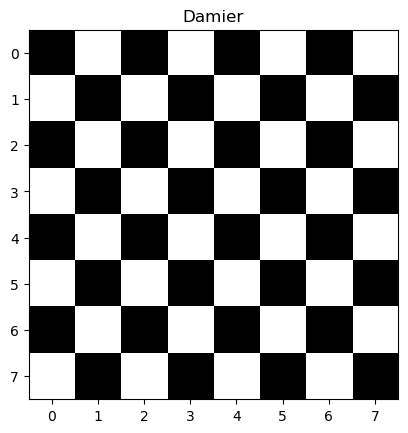

In [53]:
import matplotlib.pyplot as plt
plt.imshow(damier(8),cmap="gray")
plt.title("Damier")

**2.c** Version booléenne : écrivez `damier_bool(n)` qui renvoie le même damier (coin 0 = `False`) mais avec un `dtype` `bool`. Comparez `damier(64).nbytes` et `damier_bool(64).nbytes` et expliquez la différence dans une cellule Markdown.

In [54]:
def damier_bool(n,coin=False):
   res=np.zeros((n,n),dtype=bool)
   res[::2,::2]=coin
   res[1::2,1::2]=coin
   res[::2,1::2]=not coin
   res[1::2,::2]=not coin
   return res

damier_bool(8)

array([[False,  True, False,  True, False,  True, False,  True],
       [ True, False,  True, False,  True, False,  True, False],
       [False,  True, False,  True, False,  True, False,  True],
       [ True, False,  True, False,  True, False,  True, False],
       [False,  True, False,  True, False,  True, False,  True],
       [ True, False,  True, False,  True, False,  True, False],
       [False,  True, False,  True, False,  True, False,  True],
       [ True, False,  True, False,  True, False,  True, False]])

In [55]:
db = damier_bool(8)
assert db.dtype == bool
assert db.shape == (8, 8)
assert db.sum() == 32
assert db[0, 0] == False and db[0, 1] == True
assert damier_bool(64).nbytes == 64 * 64
print("ok")

ok


## Exercice 3 – Escaliers et pyramide (4 pts)

````{admonition} Pas encore vu en cours : np.indices
:class: note

`np.indices((n, m))` renvoie deux tableaux de forme `(n, m)` : le premier contient le numéro de ligne de chaque case, le second son numéro de colonne. Ainsi `I, J = np.indices((2, 3))` donne `I = [[0, 0, 0], [1, 1, 1]]` et `J = [[0, 1, 2], [0, 1, 2]]`. C'est la façon la plus directe de fabriquer un tableau dont la valeur dépend de la position de la case.
````

**3.a** Écrivez une fonction `escalier(n)` qui renvoie le tableau `M` de forme `(n, n)` tel que `M[i, j] == i + j`, toujours sans boucle.

In [56]:
def escalier(n):
    I,J=np.indices((n,n))
    return I+J


In [57]:
E = escalier(6)
assert E.shape == (6, 6)
assert E[0, 0] == 0 and E[5, 5] == 10 and E[2, 3] == 5
assert E.sum() == 6 * 6 * 5
assert np.array_equal(E, E.T)
print("ok")

ok


**3.b** Écrivez `pyramide(n)` qui renvoie le tableau `P` tel que `P[i, j] == |i - j|` (la distance à la diagonale). Sa diagonale est nulle et les valeurs croissent quand on s'en éloigne.

In [58]:
def pyramide(n):
     I,J=np.indices((n,n))
     return (np.abs(I-J))


In [59]:
pyramide(8)

array([[0, 1, 2, 3, 4, 5, 6, 7],
       [1, 0, 1, 2, 3, 4, 5, 6],
       [2, 1, 0, 1, 2, 3, 4, 5],
       [3, 2, 1, 0, 1, 2, 3, 4],
       [4, 3, 2, 1, 0, 1, 2, 3],
       [5, 4, 3, 2, 1, 0, 1, 2],
       [6, 5, 4, 3, 2, 1, 0, 1],
       [7, 6, 5, 4, 3, 2, 1, 0]])

In [60]:
P = pyramide(7)
assert P.shape == (7, 7)
assert np.all(np.diag(P) == 0)
assert P[0, 6] == 6 and P[6, 0] == 6 and P[2, 5] == 3
assert np.array_equal(P, P.T)
assert P.sum() == 112
print("ok")

ok


**3.c** Affichez `escalier(10)` et `pyramide(10)` avec `plt.imshow` (une figure chacun, avec un titre, et une barre de couleurs avec `plt.colorbar()`).

Puis, à l'aide d'un **seul slicing**, extrayez de `pyramide(10)` la sous-matrice `(5, 5)` formée des lignes paires et des colonnes paires, et vérifiez qu'elle vaut `2 * pyramide(5)`.

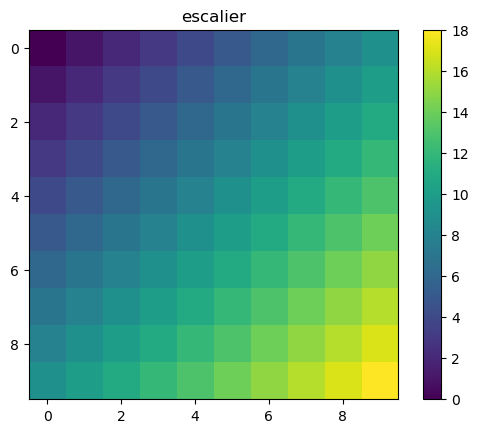

In [61]:
plt.imshow(escalier(10))
plt.title("escalier")
plt.colorbar()

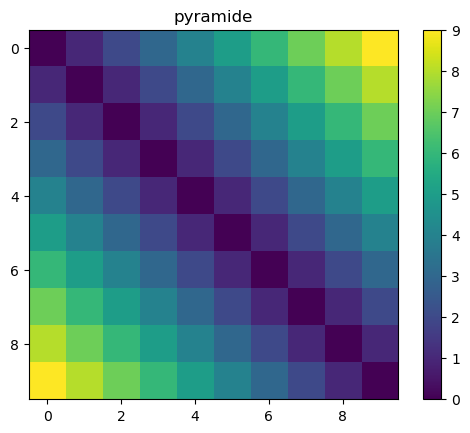

In [62]:
plt.imshow(pyramide(10))
plt.title("pyramide")
plt.colorbar()


In [63]:
pyr=pyramide(10)
sous=pyr[::2,::2]

In [64]:
assert sous.shape == (5, 5)
assert np.array_equal(sous, 2 * pyramide(5))
print("ok")

ok


## Exercice 4 – Pixel art (7 pts)

Une image couleur est un tableau de forme `(hauteur, largeur, 3)` d'entiers `uint8` : pour chaque pixel, trois valeurs entre 0 et 255 (rouge, vert, bleu). Quelques couleurs utiles :

| couleur | (R, G, B) |
|---|---|
| noir | (0, 0, 0) |
| blanc | (255, 255, 255) |
| rouge | (220, 30, 30) |
| jaune | (250, 210, 40) |
| bleu ciel | (120, 180, 240) |
| vert | (40, 170, 70) |

**4.a** Construisez une image `img` de forme `(16, 16, 3)` et de type `uint8` représentant un motif en *pixel art* de votre choix : cœur, smiley, drapeau, lettre, fantôme de Pac-Man, … Contraintes :

* le fond n'est pas noir ;
* le motif utilise **au moins trois couleurs** différentes (fond compris) ;
* tout se fait par **slicing et affectation** (`img[2:5, 6:10] = (220, 30, 30)`) : pas de boucle sur les pixels ! Une affectation par "trait" horizontal ou vertical est parfaitement acceptable, et pensez aussi aux pas (`img[::2, ...]`) pour les motifs répétitifs.

Affichez-la avec `plt.imshow(img)`.

````{admonition} Indices
:class: tip

Dessinez sur papier quadrillé 16×16 avant de coder : les lignes sont le premier indice (de haut en bas), les colonnes le second (de gauche à droite).
````

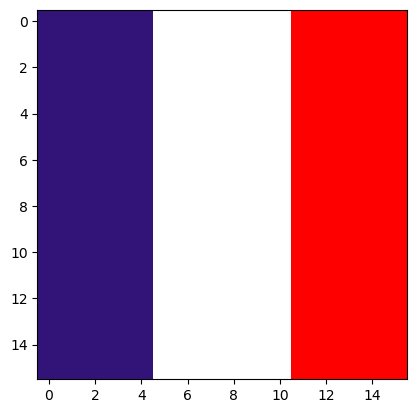

In [65]:
img=np.array([[(255,255,255)]*16]*16, dtype=np.uint8)
img[:,:5]=(50,20,120)
img[:,11:]=(255,0,0)
plt.imshow(img)

In [66]:
assert img.shape == (16, 16, 3)
assert img.dtype == np.uint8
couleurs = np.unique(img.reshape(-1, 3), axis=0)
assert len(couleurs) >= 3, "il faut au moins 3 couleurs"
assert not np.array_equal(img[0, 0], (0, 0, 0)), "le fond ne doit pas être noir"
print("ok :", len(couleurs), "couleurs")

ok : 3 couleurs


````{admonition} Pas encore vu en cours : np.repeat
:class: note

`np.repeat(tab, k, axis=...)` duplique `k` fois de suite chaque élément le long de l'axe indiqué : `np.repeat(np.array([1, 2]), 3)` vaut `[1, 1, 1, 2, 2, 2]`. Sur un tableau à plusieurs dimensions, `axis=0` répète les lignes et `axis=1` les colonnes ; la taille de l'axe concerné est multipliée par `k`.
````

**4.b** L'image est minuscule. Agrandissez-la d'un facteur 20 dans chaque direction avec `np.repeat` (une fois le long de l'axe 0, une fois le long de l'axe 1) : chaque pixel devient un carré de 20×20 pixels. Le résultat `grande` a la forme `(320, 320, 3)`. Affichez-le.

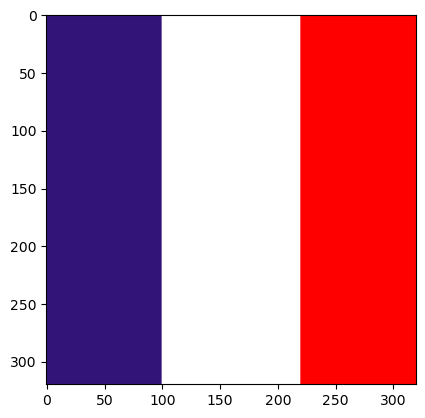

In [67]:
img2=np.repeat(img,20,axis=0)
grande=np.repeat(img2,20,axis=1)
plt.imshow(grande)

In [68]:
assert grande.shape == (320, 320, 3)
assert grande.dtype == np.uint8
assert np.array_equal(grande[::20, ::20], img)
assert np.array_equal(grande[0:20, 0:20], np.broadcast_to(img[0, 0], (20, 20, 3)))
print("ok")

ok


````{admonition} Pas encore vu en cours : les agrégations avec axis=
:class: note

`tab.sum()`, `tab.mean()`, `tab.max()`… travaillent par défaut sur tout le tableau, mais l'argument `axis=` permet de ne réduire qu'une dimension : pour un tableau de forme `(4, 5, 3)`, `tab.mean(axis=2)` moyenne les 3 valeurs de la dernière dimension et renvoie un tableau `(4, 5)`. Retenez bien que l'axe qu'on donne est celui qui disparaît ! Nous verrons les agrégations en séance 2.
````

**4.c** Niveaux de gris. Construisez `gris`, tableau `(320, 320)` de type `uint8` où chaque pixel vaut la **moyenne** de ses trois canaux.

````{admonition} Piège : l'arithmétique en uint8
:class: warning

Testez d'abord la cellule ci-dessous. Que vaut `np.uint8(200) + np.uint8(100)` ? Pouvez-vous deviner pourquoi ?
En conséquence, `(grande[:, :, 0] + grande[:, :, 1] + grande[:, :, 2]) / 3` est **faux** ! Il faut convertir en flottants *avant* d'additionner (par ex. avec `grande.astype(float)`), ou bien utiliser `grande.mean(axis=2)` qui calcule la moyenne le long du troisième axe (les canaux) et renvoie des flottants. On revient ensuite en `uint8` avec `astype(np.uint8)`.
````

In [69]:
a = np.array([200], dtype=np.uint8)
b = np.array([100], dtype=np.uint8)
print(a + b, (a + b).dtype)

[44] uint8


Expliquez le résultat ci-dessus en une phrase (cellule Markdown), puis calculez `gris` et affichez-le avec `plt.imshow(gris, cmap="gray")`.

on moyenne d abord chaque case avec la fonction mean, puis on converti les éléments de l image en 8 bits et on passe aux nuances de gris.

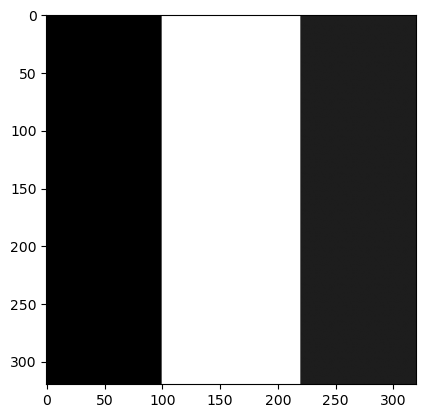

In [70]:
gris=grande.mean(axis=2)
gris2=gris.astype(np.uint8)
plt.imshow(gris2,cmap="gray")


In [71]:
assert gris2.shape == (320, 320)
assert gris2.dtype == np.uint8
attendu = (grande[:, :, 0].astype(float) + grande[:, :, 1] + grande[:, :, 2]) / 3
assert np.all(np.abs(gris2.astype(float) - attendu) <= 1)
print("ok")


ok


````{admonition} Pas encore vu en cours : les comparaisons entre tableaux
:class: note

Une comparaison s'applique case par case et renvoie un tableau de booléens de même forme : `np.array([1, 5, 9]) > 4` vaut `[False, True, True]`. On appelle cela un *masque* ; `astype(np.uint8)` le convertit ensuite en 0 et 1. On travaillera les masques en séance 2.
````

**4.d** Seuillage. Construisez `noir_blanc`, image `(320, 320)` de type `uint8` qui vaut 255 (blanc) là où `gris` est strictement supérieur à 127 et 0 (noir) ailleurs. Affichez-la.

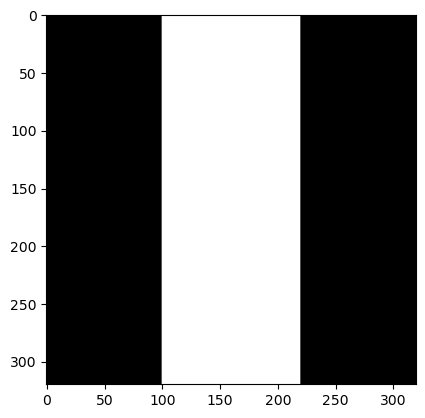

In [72]:
seuillage=gris2>127
noir_blanc=seuillage.astype(np.uint8)*255
plt.imshow(noir_blanc,cmap="gray")

In [73]:
assert noir_blanc.shape == (320, 320)
assert noir_blanc.dtype == np.uint8
assert set(np.unique(noir_blanc)) <= {0, 255}
assert np.all((noir_blanc == 255) == (gris2 > 127))
print("ok")

ok


**4.e** Sauvegarde. Enregistrez `grande` dans `pixel_art.png` et `gris` dans `pixel_art_gris.png` avec `plt.imsave` (pour l'image en gris, précisez `cmap="gray"`). Relisez ensuite `pixel_art.png` avec `plt.imread` dans une variable `relue` : quelle est sa forme ? son `dtype` ? Ses valeurs sont-elles entre 0 et 255 ? Commentez en une ou deux phrases.

In [74]:
plt.imsave('pixel_art.png',grande)
plt.imsave('pixel_art_gris.png',gris2,cmap="gray")

In [75]:
image=plt.imread('pixel_art.png')
image2=plt.imread('pixel_art_gris.png')

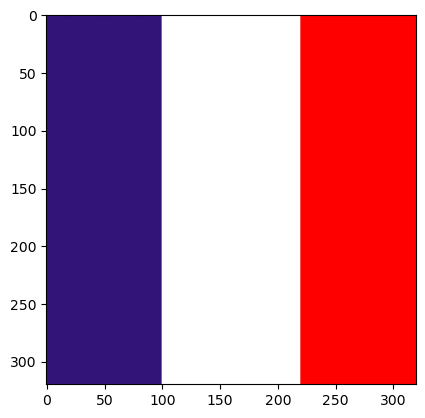

In [76]:
plt.imshow(image)

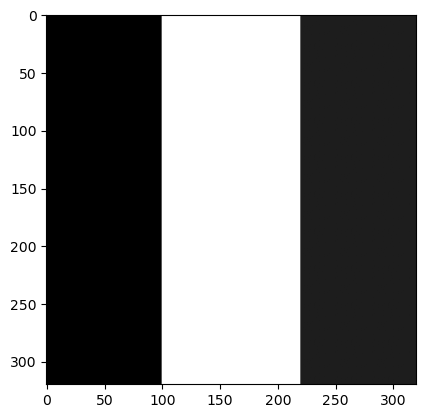

In [77]:
plt.imshow(image2)

In [78]:
import os
assert os.path.exists("pixel_art.png") and os.path.exists("pixel_art_gris.png")
assert image.shape[:2] == (320, 320)
print("ok")

ok


## Bonus (+2) – Négatif, miroir, vues

**B.1** Le négatif d'une image s'obtient en remplaçant chaque valeur `v` par `255 - v`. Calculez le négatif de `grande` et affichez-le. Quel est son `dtype` ?

**B.2** Affichez l'image miroir (gauche-droite) de `grande`, puis l'image retournée (haut-bas), avec du slicing à pas négatif.

**B.3** Vues et copies. Exécutez les lignes suivantes, observez et expliquez en deux phrases ce qui se passe sur `grande` ; puis proposez la modification qui évite de toucher à `grande`.

```python
coin = grande[:40, :40]
coin[:, :] = (0, 0, 0)
plt.imshow(grande)
```

Vérifiez votre explication avec `np.shares_memory(coin, grande)`.

Bon courage à tous ! Pour toute question sur le sujet, vous pouvez me contacter par email : [raphael@imagine-app.fr](mailto:raphael@imagine-app.fr).

Au plaisir de vous lire,

votre responsable de cours, Raphael Prasquier
(sujet conçu par Aurélien Noce)

In [79]:
# votre code